Import Simulator from library:

In [1]:
from python_kinetic_simulator.simulator import Simulator

Set up a simulation and run it:

In [2]:
# initialize simulator and its temperature (in °C)
sim = Simulator(T_C=50)

# add species, concentrations (M) and relative energies (kcal/mol).
# Default values for energy and concentration are 0.
sim.add_species("A", conc=1)
sim.add_species("B", energy=-2)
sim.add_species("B(adsorbed)", energy=-2.5)
sim.add_species("C", energy=-30)

# add reactions by specifying their activation
# energy (in kcal/mol)
sim.add_reaction(["A"], ["B", "B"], ts_energy=23.0)

# or their rate constant (in M^n * s^-1)
sim.add_reaction(["B"], ["C"], rate=5e-4)

# it is also possible to enforce a K_eq (overriding
# the energy value assigned to the involved species).
# The rate of the reaction will be assumed as fast,
# to ensure equilibration at any point in time.
sim.add_reaction(["B"], ["B(adsorbed)"], enforced_K_eq=2.18)

# specify the timeframe of the simulation and run it
sim.run(time=10, t_units="h")

# running simulations with time=0 is also possible
# to get equilibrium concentrations
# sim.run(time=0)

+---+------------------+-----------------+----------+--------------------------------------+
| # |     Reaction     | Faster k (s^-1) |   K_eq   |              Speed Rank              |
+---+------------------+-----------------+----------+--------------------------------------+
| 1 |    A -> B + B    |     1.83e-03    | 5.09e+02 | KINETIC, SLOW:  evolved step-by-step |
| 2 |      B -> C      |     5.00e-04    | 8.89e+18 | KINETIC, SLOW:  evolved step-by-step |
| 3 | B -> B(adsorbed) |      N / A      | 2.18e+00 | THERMODYNAMIC: always at equilibrium |
+---+------------------+-----------------+----------+--------------------------------------+

--> Running simulation for 10 h with the LSODA method (36.0 s increments, 1000 iterations)
--> Pre-equilibrated 1 THERMODYNAMIC and FAST reactions before starting the main loop.
Iterations  |##################################################| 100.0% 

--> Simulation complete (0.8 s)


Show results:


Final Concentrations:


A           : 0.00 M (0.0 % of initial conc., 100.00 % consumed)
B           : 0.00 M (0.12 % total molar fraction)
B(adsorbed) : 0.01 M (0.27 % total molar fraction)
C           : 1.99 M (99.61 % total molar fraction)



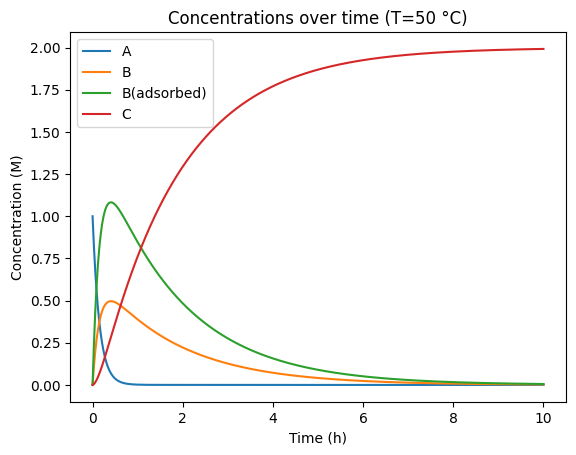

In [3]:
sim.show()

Only visualize the evolution of some species:


Final Concentrations:
B           : 0.00 M (0.12 % total molar fraction)
B(adsorbed) : 0.01 M (0.27 % total molar fraction)



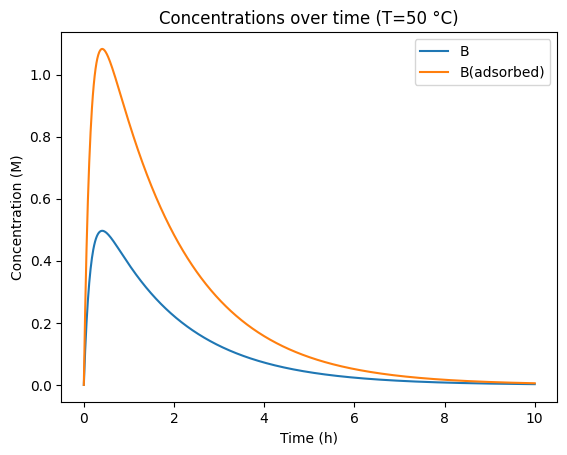

In [4]:
sim.show(species=("B", "B(adsorbed)"))

Simulator data is available for further manipulation:

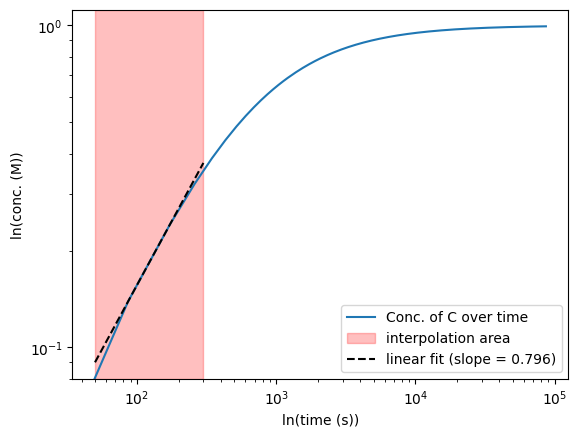

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# plot [C] vs. time in a loglog plot
C_concs = sim.results["C"]
plt.loglog(sim.time_data, C_concs, label="Conc. of C over time")
plt.xlabel("ln(time (s))")
plt.ylabel("ln(conc. (M))")

# define and plot an interpolation time range
start, end = 5e1, 3e2  # 1E3
plt.axvspan(start, end, color="red", alpha=0.25, label="interpolation area")

# get boundary indices of arrays
start_idx = next(index + 1 for index, value in enumerate(sim.time_data[1:]) if value > start)
end_idx = (
    len(sim.time_data)
    - 2
    - next(index for index, value in enumerate(reversed(sim.time_data[:-1])) if value < end)
)

# fit line through logarithms, in the defined range
log_time_interp = np.log(sim.time_data[start_idx:end_idx])
log_conc_interp = np.log(C_concs[start_idx:end_idx])
X = np.vstack([log_time_interp, np.ones(log_time_interp.shape[0])]).T
m, c = np.linalg.lstsq(X, log_conc_interp, rcond=None)[0]

# draw an interpolation line
x_fit = (start, end)
y_fit = (start**m * np.exp(c), end**m * np.exp(c))
plt.plot(
    x_fit,
    y_fit,
    label=f"linear fit (slope = {m:.3f})",
    color="black",
    linestyle="dashed",
    markersize=4,
)
_ = plt.legend()

It is also possible to track how much material was obtained through different pathways:

+---+----------------+-----------------+----------+--------------------------------------+
| # |    Reaction    | Faster k (s^-1) |   K_eq   |              Speed Rank              |
+---+----------------+-----------------+----------+--------------------------------------+
| 1 |     A -> B     |     5.13e-02    | 2.59e-01 | KINETIC, SLOW:  evolved step-by-step |
| 2 | A + B -> C + C |     1.25e-03    | 3.95e+44 | KINETIC, SLOW:  evolved step-by-step |
| 3 | A + A -> C + C |     1.05e-03    | 1.02e+44 | KINETIC, SLOW:  evolved step-by-step |
+---+----------------+-----------------+----------+--------------------------------------+

--> Running simulation for 24 h with the LSODA method (86.4 s increments, 1000 iterations)
Iterations  |##################################################| 100.0% 

--> Simulation complete (0.4 s)

Final Concentrations:
A : 0.01 M (0.5 % of initial conc., 99.47 % consumed)
B : 0.00 M (0.14 % total molar fraction)
C : 0.99 M (99.34 % total molar fraction)

Reac

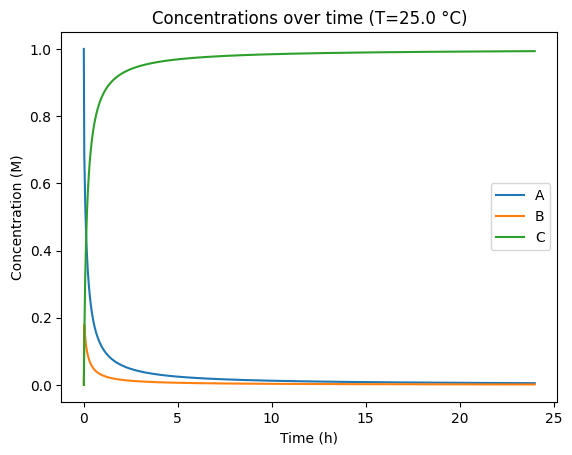

In [10]:
sim = Simulator()

sim.add_species("A", conc=1)
sim.add_species("B", energy=0.8)
sim.add_species("C", energy=-30)

sim.add_reaction(["A"], ["B"], ts_energy=20.0)
sim.add_reaction(["A", "B"], ["C", "C"], ts_energy=22.2, throughput_tgt="C")
sim.add_reaction(["A", "A"], ["C", "C"], ts_energy=21.5, throughput_tgt="C")

sim.run(time=24, t_units="h")

sim.show()